In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from sympy.printing.pytorch import torch
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST


In [24]:
# establishing the seed values

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# PyTorch global seed (CPU + default device behavior)
torch.manual_seed(SEED)

# MPS (for MacBook)
if torch.backends.mps.is_built() and torch.backends.mps.is_available():
	device = torch.device("mps")
	torch.mps.manual_seed(SEED)

elif torch.cuda.is_available():
	device = torch.device("cuda")

else:
	device = torch.device("cpu")

## Downloading the Dataset
This dataset has a special class, the MNIST class, which is used to download and apply transformations to the dataset.

The pre-trained CNN I will be using for my first model, MobileNetV2, requires 3 channels and images of size 224x224, so the images are transformed to match these requirements.

In [5]:
# This transformation changes the images to the format MobileNetV2 expects
transform_mobilenet = transforms.Compose([
	# the images are in single channel black and white, so we need to make this 3 channels
	transforms.Grayscale(num_output_channels=3),
	transforms.Resize(224),
	transforms.ToTensor(),
	transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# This transform is for the "from scratch" model and uses the standard MNIST normalize values
transform_scratch = transforms.Compose([
	transforms.ToTensor(),
	transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load the training data
# The MNIST class provides a way to download and apply transformations to the MNIST images

# For Model 1
trainset_mobilenet = MNIST(
	root='./data_mobilenet',      # Directory where data will be saved
	train=True,         # Request the training subset
	download=True,      # Download the data if it's not already present
	transform=transform_mobilenet
)

testset_mobilenet = MNIST(
	root='./data_mobilenet',      # Directory where data will be saved
	train=False,        # Request the test subset
	download=True,      # Download the data if it's not already present
	transform=transform_mobilenet
)

# For Model 2
trainset_scratch = MNIST(
	root='./data_scratch',      # Directory where data will be saved
	train=True,         # Request the training subset
	download=True,      # Download the data if it's not already present
	transform=transform_scratch
)

testset_scratch = MNIST(
	root='./data_scratch',      # Directory where data will be saved
	train=False,        # Request the test subset
	download=True,      # Download the data if it's not already present
	transform=transform_scratch
)

## EDA
This dataset contains 70,000 handwritten digits. The images and labels are currently in four variables:
* trainset_mobilenet: greyscale, 224x224, 60,000 images
* testset_mobilenet: greyscale, 224x224, 10,000 images
* trainset_scratch: black and white, 28x28, 60,000 images (original format)
* testset_scratch: black and white, 28x28, 10,000 images (original format)

One can access the individual images via the indices, which is demonstrated below.


In [14]:
# Picking two images at random.
image_tensor1, label1 = testset_mobilenet[10]
image_tensor2, label2 = testset_mobilenet[100]

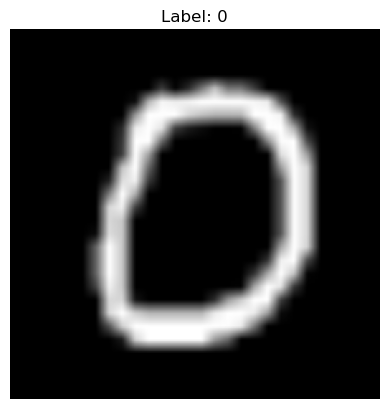

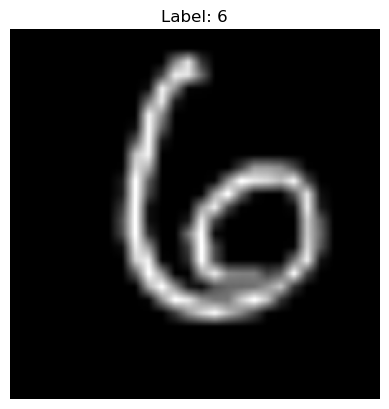

In [15]:
#    For plotting, we need to remove the channel dimension (which is 1 for grayscale)
#    and use a 'gray' colormap.
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def to_display_gray(x):
	# x: Tensor [3, H, W] normalized
	x = x.detach().cpu()
	x = x * IMAGENET_STD + IMAGENET_MEAN  # unnormalize
	x = x.clamp(0, 1)
	return x[0].numpy()                   # take the first channel -> [H, W]

plt.imshow(to_display_gray(image_tensor1), cmap='gray')
plt.title(f"Label: {label1}")
plt.axis('off') # Hide axis values
plt.show()

plt.imshow(to_display_gray(image_tensor2), cmap='gray')
plt.title(f"Label: {label2}")
plt.axis('off') # Hide axis values
plt.show()

In [26]:
# create the data loaders
train_loader_mobilenet = DataLoader(trainset_mobilenet, batch_size=32, shuffle=True)
val_loader_mobilenet = DataLoader(testset_mobilenet, batch_size=32, shuffle=False)

train_loader_scratch = DataLoader(trainset_scratch, batch_size=32, shuffle=True)
val_loader_scratch = DataLoader(testset_scratch, batch_size=32, shuffle=False)


## Model 1: Intro
For the first model, we will use a pre-trained MobileNetV2 to classify digits by freezing its learned visual features and training a small new classifier on top.

In [59]:
# use pretrained MobileNet CNN
class DigitClassifierMobileNet(nn.Module):
	def __init__(self, num_classes=10, dropout_rate=0.0, inner_size=128):
		super(DigitClassifierMobileNet, self).__init__()

		# Load pre-trained MobileNetV2
		self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

		# Freeze base model parameters
		for param in self.base_model.parameters():
			param.requires_grad = False

		# Remove original classifier
		self.base_model.classifier = nn.Identity()

		# Add custom layers
		self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
		self.inner = nn.Linear(1280, inner_size)  # New inner layer
		self.relu = nn.ReLU()
		self.dropout = nn.Dropout(dropout_rate)  # Add dropout
		self.output_layer = nn.Linear(inner_size, num_classes)

	def forward(self, x):
		x = self.base_model.features(x)
		x = self.global_avg_pooling(x)
		x = torch.flatten(x, 1)
		x = self.inner(x)
		x = self.relu(x)
		x = self.dropout(x)  # Apply dropout
		x = self.output_layer(x)
		return x

In [19]:
# offload tensor computations and neural network inference to the GPU (Apple’s Metal Performance Shaders (MPS))
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [61]:
model = DigitClassifierMobileNet(num_classes=10)
model.to(device)

# set the optimizer and the learning rate (lower learning rate = longer processing time)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# set the criterion model to measure the error
criterion = nn.CrossEntropyLoss()

### Model 1 Part 1: Running Model 1 for the First Time

In [63]:
# Training loop
num_epochs = 10

epoch_stats = pd.DataFrame()

for epoch in range(num_epochs):
	# Training phase
	model.train()  # Set the model to training mode
	running_loss = 0.0
	correct = 0
	total = 0

	# Iterate over the training data
	for inputs, labels in train_loader_mobilenet:
		# Move data to the specified device (GPU or CPU)
		inputs, labels = inputs.to(device), labels.to(device)

		# Zero the parameter gradients to prevent accumulation
		optimizer.zero_grad()
		# Forward pass
		outputs = model(inputs)
		# Calculate the loss
		loss = criterion(outputs, labels)
		# Backward pass and optimize
		loss.backward()
		optimizer.step()

		# Accumulate training loss
		running_loss += loss.item()
		# Get predictions
		_, predicted = torch.max(outputs.data, 1)
		# Update total and correct predictions
		total += labels.size(0)
		correct += (predicted == labels).sum().item()

	# Calculate average training loss and accuracy
	train_loss = running_loss / len(train_loader_mobilenet)
	train_acc = correct / total

	# Validation phase
	model.eval()  # Set the model to evaluation mode
	val_loss = 0.0
	val_correct = 0
	val_total = 0

	# Disable gradient calculation for validation
	with torch.no_grad():
		# Iterate over the validation data
		for inputs, labels in val_loader_mobilenet:
			# Move data to the specified device (GPU or CPU)
			inputs, labels = inputs.to(device), labels.to(device)
			# Forward pass
			outputs = model(inputs)
			# Calculate the loss
			loss = criterion(outputs, labels)

			# Accumulate validation loss
			val_loss += loss.item()
			# Get predictions
			_, predicted = torch.max(outputs.data, 1)
			# Update total and correct predictions
			val_total += labels.size(0)
			val_correct += (predicted == labels).sum().item()

	# Calculate average validation loss and accuracy
	val_loss /= len(val_loader_mobilenet)
	val_acc = val_correct / val_total

	# Print epoch results
	print(f'Epoch {epoch+1}/{num_epochs}')
	print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
	print(f'    Val Loss: {val_loss:.4f},   Val Acc: {val_acc:.4f}')

	epoch_stats = pd.concat([epoch_stats, pd.DataFrame(data={'epoch': epoch+1,'train_loss': train_loss, 'train_acc': train_acc,
													   'val_loss': val_loss, 'val_acc': val_acc}, index=[epoch])] )

Epoch 1/10
  Train Loss: 0.2732, Train Acc: 0.9154
    Val Loss: 0.1500,   Val Acc: 0.9559
Epoch 2/10
  Train Loss: 0.2266, Train Acc: 0.9338
    Val Loss: 0.1684,   Val Acc: 0.9490
Epoch 3/10
  Train Loss: 0.2009, Train Acc: 0.9422
    Val Loss: 0.1410,   Val Acc: 0.9614
Epoch 4/10
  Train Loss: 0.1844, Train Acc: 0.9482
    Val Loss: 0.1677,   Val Acc: 0.9573
Epoch 5/10
  Train Loss: 0.1843, Train Acc: 0.9499
    Val Loss: 0.1515,   Val Acc: 0.9573
Epoch 6/10
  Train Loss: 0.1805, Train Acc: 0.9518
    Val Loss: 0.1661,   Val Acc: 0.9580
Epoch 7/10
  Train Loss: 0.1701, Train Acc: 0.9534
    Val Loss: 0.1830,   Val Acc: 0.9522
Epoch 8/10
  Train Loss: 0.1661, Train Acc: 0.9550
    Val Loss: 0.1755,   Val Acc: 0.9597
Epoch 9/10
  Train Loss: 0.1624, Train Acc: 0.9553
    Val Loss: 0.1428,   Val Acc: 0.9643
Epoch 10/10
  Train Loss: 0.1592, Train Acc: 0.9584
    Val Loss: 0.1320,   Val Acc: 0.9672


<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

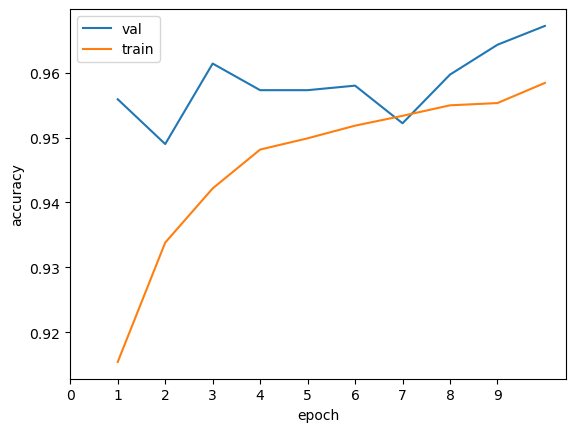

In [64]:
plt.plot(epoch_stats['epoch'], epoch_stats['val_acc'], label='val')
plt.plot(epoch_stats['epoch'], epoch_stats['train_acc'], label='train')
plt.xticks(np.arange(10))
plt.legend()
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.plot


The model's accuracy remained between .95 and .97 throughout the epochs.

### Model 1 Part 2: Fine-Tuning the Model

To fine-tune this model, these three interacting hyperparameters are jointly tuned:

* learning rate: [.01, .001, .0001]
* dropout rate: [0.0, 0.2, 0.3]
* hidden layer size: [128, 256, 512]

In [65]:
# creates new instances of the model
def make_model_mobilenet(learning_rate, dropout_rate, inner_size):
	model = DigitClassifierMobileNet(num_classes=10, dropout_rate=dropout_rate, inner_size=inner_size)
	model.to(device)
	optimizer = optim.Adam(model.parameters(), lr=learning_rate)
	return model, optimizer


mobilenet_tuning_stats = pd.DataFrame()
index = 0

for lr in [.01, .001, .0001]:
	for dropout_rate in [0.0, 0.2, 0.3]:
		for inner_size in [128, 256, 512]:
			model, optimizer = make_model_mobilenet(learning_rate=lr, dropout_rate=dropout_rate, inner_size=inner_size)
			model.train()  # Set the model to training mode
			running_loss = 0.0
			correct = 0
			total = 0

			# Iterate over the training data
			for inputs, labels in train_loader_mobilenet:
				# Move data to the specified device (GPU or CPU)
				inputs, labels = inputs.to(device), labels.to(device)

				# Zero the parameter gradients to prevent accumulation
				optimizer.zero_grad()
				# Forward pass
				outputs = model(inputs)
				# Calculate the loss
				loss = criterion(outputs, labels)
				# Backward pass and optimize
				loss.backward()
				optimizer.step()

				# Accumulate training loss
				running_loss += loss.item()
				# Get predictions
				_, predicted = torch.max(outputs.data, 1)
				# Update total and correct predictions
				total += labels.size(0)
				correct += (predicted == labels).sum().item()

			# Calculate average training loss and accuracy
			train_loss = running_loss / len(train_loader_mobilenet)
			train_acc = correct / total

			# Validation phase
			model.eval()  # Set the model to evaluation mode
			val_loss = 0.0
			val_correct = 0
			val_total = 0

			# Disable gradient calculation for validation
			with torch.no_grad():
				# Iterate over the validation data
				for inputs, labels in val_loader_mobilenet:
					# Move data to the specified device (GPU or CPU)
					inputs, labels = inputs.to(device), labels.to(device)
					# Forward pass
					outputs = model(inputs)
					# Calculate the loss
					loss = criterion(outputs, labels)

					# Accumulate validation loss
					val_loss += loss.item()
					# Get predictions
					_, predicted = torch.max(outputs.data, 1)
					# Update total and correct predictions
					val_total += labels.size(0)
					val_correct += (predicted == labels).sum().item()

			# Calculate average validation loss and accuracy
			val_loss /= len(val_loader_mobilenet)
			val_acc = val_correct / val_total

		# Print learning rate results
			print(f'_______________________________________')
			print(f'  Learning rate: {lr}                 ')
			print(f'  Dropout rate: {dropout_rate}        ')
			print(f'  Inner layer size: {inner_size}      ')
			print(f'_______________________________________')
			print(f'   → Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
			print(f'   → Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}\n')


			mobilenet_tuning_stats = pd.concat([mobilenet_tuning_stats, pd.DataFrame(data={'learning_rate': lr,'dropout_rate': dropout_rate, 'inner_size': inner_size,
																	   'train_loss': train_loss, 'train_acc': train_acc,
																'val_loss': val_loss, 'val_acc': val_acc}, index=[index])] )
			index += 1

_______________________________________
  Learning rate: 0.01                 
  Dropout rate: 0.0        
  Inner layer size: 128      
_______________________________________
   → Train Loss: 0.3831, Train Acc: 0.8803
   → Val Loss: 0.2098, Val Acc: 0.9322

_______________________________________
  Learning rate: 0.01                 
  Dropout rate: 0.0        
  Inner layer size: 256      
_______________________________________
   → Train Loss: 0.3551, Train Acc: 0.8908
   → Val Loss: 0.2075, Val Acc: 0.9371

_______________________________________
  Learning rate: 0.01                 
  Dropout rate: 0.0        
  Inner layer size: 512      
_______________________________________
   → Train Loss: 0.3816, Train Acc: 0.8903
   → Val Loss: 0.2080, Val Acc: 0.9342

_______________________________________
  Learning rate: 0.01                 
  Dropout rate: 0.2        
  Inner layer size: 128      
_______________________________________
   → Train Loss: 0.7646, Train Acc: 0.7320


Here are the top 5 validation accuracy rates, along with the hyperparameters:

In [67]:
mobilenet_tuning_stats.sort_values(['val_acc'], ascending=False).head(5)

,learning_rate,dropout_rate,inner_size,train_loss,train_acc,val_loss,val_acc
17,0.001,0.3,512,0.309285,0.899800,0.122537,0.9630
12,0.001,0.2,128,0.321822,0.899383,0.131601,0.9598
14,0.001,0.2,512,0.294474,0.905483,0.127309,0.9584
9,0.001,0.0,128,0.268857,0.916667,0.131543,0.9567
16,0.001,0.3,256,0.319390,0.898117,0.145563,0.9534


### Model 1 Part 3: Results
The first model was shown to have the highest validation accuracy with these hyperparameter values:
* learning rate: .001
* dropout rate: 0.3
* hidden layer size: 512

### Model 2: Intro

The second model will be built without a pre-trained CNN. The CNN in this case will be multiple Sequential layers, followed by a dense layer and an output layer.

In [42]:
# create a model from scratch
class DigitClassifierScratch(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.0, inner_size=120):
        super(DigitClassifierScratch, self).__init__()

        # for extracting features
        self.layer1 = nn.Sequential(
	        nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
	        nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.layer2 = nn.Sequential(
	        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
	        nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.layer3 = nn.Sequential(
	        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
	        nn.MaxPool2d(kernel_size=2, stride=2),
	        nn.AdaptiveAvgPool2d((1,1))
        )

        # dense layers
        self.flatten = nn.Flatten(1)

        self.inner_layer = nn.Linear(
            in_features = 64,
	        out_features = inner_size
        )
        self.ReLU = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.output_layer = nn.Linear(
            in_features = inner_size,
	        out_features = num_classes
        )

    def forward(self, x):
	    x = self.layer1(x)
	    x = self.layer2(x)
	    x = self.layer3(x)

	    x = self.flatten(x)
	    x = self.inner_layer(x)
	    x = self.ReLU(x)
	    x = self.dropout(x)
	    x = self.output_layer(x)

	    return x

In [41]:
model = DigitClassifierScratch(num_classes=10)
model.to(device)

# set the optimizer and the learning rate (lower learning rate = longer processing time)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# set the criterion model to measure the error
criterion = nn.CrossEntropyLoss()

In [44]:
# Training loop
num_epochs = 10

epoch_stats = pd.DataFrame()

for epoch in range(num_epochs):
	# Training phase
	model.train()  # Set the model to training mode
	running_loss = 0.0
	correct = 0
	total = 0

	# Iterate over the training data
	for inputs, labels in train_loader_scratch:
		# Move data to the specified device (GPU or CPU)
		inputs, labels = inputs.to(device), labels.to(device)

		# Zero the parameter gradients to prevent accumulation
		optimizer.zero_grad()
		# Forward pass
		outputs = model(inputs)
		# Calculate the loss
		loss = criterion(outputs, labels)
		# Backward pass and optimize
		loss.backward()
		optimizer.step()

		# Accumulate training loss
		running_loss += loss.item()
		# Get predictions
		_, predicted = torch.max(outputs.data, 1)
		# Update total and correct predictions
		total += labels.size(0)
		correct += (predicted == labels).sum().item()

	# Calculate average training loss and accuracy
	train_loss = running_loss / len(train_loader_scratch)
	train_acc = correct / total

	# Validation phase
	model.eval()  # Set the model to evaluation mode
	val_loss = 0.0
	val_correct = 0
	val_total = 0

	# Disable gradient calculation for validation
	with torch.no_grad():
		# Iterate over the validation data
		for inputs, labels in val_loader_scratch:
			# Move data to the specified device (GPU or CPU)
			inputs, labels = inputs.to(device), labels.to(device)
			# Forward pass
			outputs = model(inputs)
			# Calculate the loss
			loss = criterion(outputs, labels)

			# Accumulate validation loss
			val_loss += loss.item()
			# Get predictions
			_, predicted = torch.max(outputs.data, 1)
			# Update total and correct predictions
			val_total += labels.size(0)
			val_correct += (predicted == labels).sum().item()

	# Calculate average validation loss and accuracy
	val_loss /= len(val_loader_scratch)
	val_acc = val_correct / val_total

	# Print epoch results
	print(f'Epoch {epoch+1}/{num_epochs}')
	print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
	print(f'    Val Loss: {val_loss:.4f},   Val Acc: {val_acc:.4f}')

	epoch_stats = pd.concat([epoch_stats, pd.DataFrame(data={'epoch': epoch+1,'train_loss': train_loss, 'train_acc': train_acc,
													   'val_loss': val_loss, 'val_acc': val_acc}, index=[epoch])] )

Epoch 1/10
  Train Loss: 0.1062, Train Acc: 0.9679
    Val Loss: 0.0646,   Val Acc: 0.9800
Epoch 2/10
  Train Loss: 0.0709, Train Acc: 0.9775
    Val Loss: 0.0462,   Val Acc: 0.9849
Epoch 3/10
  Train Loss: 0.0504, Train Acc: 0.9842
    Val Loss: 0.0453,   Val Acc: 0.9847
Epoch 4/10
  Train Loss: 0.0413, Train Acc: 0.9869
    Val Loss: 0.0308,   Val Acc: 0.9901
Epoch 5/10
  Train Loss: 0.0349, Train Acc: 0.9891
    Val Loss: 0.0301,   Val Acc: 0.9897
Epoch 6/10
  Train Loss: 0.0294, Train Acc: 0.9910
    Val Loss: 0.0342,   Val Acc: 0.9883
Epoch 7/10
  Train Loss: 0.0251, Train Acc: 0.9922
    Val Loss: 0.0221,   Val Acc: 0.9927
Epoch 8/10
  Train Loss: 0.0220, Train Acc: 0.9927
    Val Loss: 0.0256,   Val Acc: 0.9915
Epoch 9/10
  Train Loss: 0.0201, Train Acc: 0.9933
    Val Loss: 0.0300,   Val Acc: 0.9903
Epoch 10/10
  Train Loss: 0.0166, Train Acc: 0.9943
    Val Loss: 0.0251,   Val Acc: 0.9919


<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

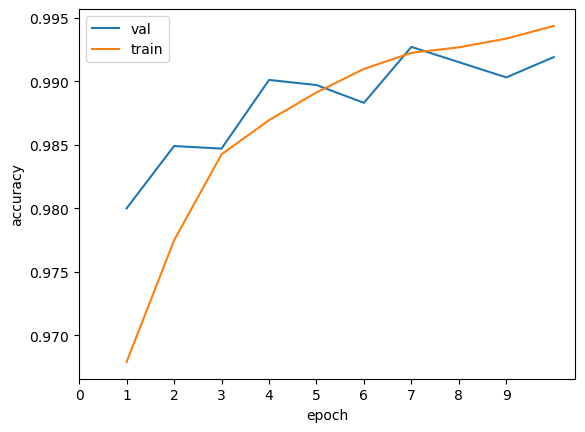

In [45]:
plt.plot(epoch_stats['epoch'], epoch_stats['val_acc'], label='val')
plt.plot(epoch_stats['epoch'], epoch_stats['train_acc'], label='train')
plt.xticks(np.arange(10))
plt.legend()
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.plot

The model's accuracy remained between .980 and .994 throughout the epochs.

### Model 2 Part 2: Fine-Tuning the Model

To fine-tune this model, these three interacting hyperparameters are jointly tuned:

* learning rate: [.0001, .001, .01]
* dropout rate: [0.0, 0.2, 0.3]
* hidden layer size: [120, 240, 480]

In [70]:
# creates new instances of the model
def make_model_scratch(learning_rate, dropout_rate, inner_size):
	model = DigitClassifierScratch(num_classes=10, dropout_rate=dropout_rate, inner_size=inner_size)
	model.to(device)
	optimizer = optim.Adam(model.parameters(), lr=learning_rate)
	return model, optimizer


scratch_tuning_stats = pd.DataFrame()
index = 0

for lr in [.01, .001, .0001]:
	for dropout_rate in [0.0, 0.2, 0.3]:
		for inner_size in [120, 240, 480]:
			model, optimizer = make_model_scratch(learning_rate=lr, dropout_rate=dropout_rate, inner_size=inner_size)
			model.train()  # Set the model to training mode
			running_loss = 0.0
			correct = 0
			total = 0

			# Iterate over the training data
			for inputs, labels in train_loader_scratch:
				# Move data to the specified device (GPU or CPU)
				inputs, labels = inputs.to(device), labels.to(device)

				# Zero the parameter gradients to prevent accumulation
				optimizer.zero_grad()
				# Forward pass
				outputs = model(inputs)
				# Calculate the loss
				loss = criterion(outputs, labels)
				# Backward pass and optimize
				loss.backward()
				optimizer.step()

				# Accumulate training loss
				running_loss += loss.item()
				# Get predictions
				_, predicted = torch.max(outputs.data, 1)
				# Update total and correct predictions
				total += labels.size(0)
				correct += (predicted == labels).sum().item()

			# Calculate average training loss and accuracy
			train_loss = running_loss / len(train_loader_scratch)
			train_acc = correct / total

			# Validation phase
			model.eval()  # Set the model to evaluation mode
			val_loss = 0.0
			val_correct = 0
			val_total = 0

			# Disable gradient calculation for validation
			with torch.no_grad():
				# Iterate over the validation data
				for inputs, labels in val_loader_scratch:
					# Move data to the specified device (GPU or CPU)
					inputs, labels = inputs.to(device), labels.to(device)
					# Forward pass
					outputs = model(inputs)
					# Calculate the loss
					loss = criterion(outputs, labels)

					# Accumulate validation loss
					val_loss += loss.item()
					# Get predictions
					_, predicted = torch.max(outputs.data, 1)
					# Update total and correct predictions
					val_total += labels.size(0)
					val_correct += (predicted == labels).sum().item()

			# Calculate average validation loss and accuracy
			val_loss /= len(val_loader_scratch)
			val_acc = val_correct / val_total

			# Print learning rate results
			print(f'_______________________________________')
			print(f'  Learning rate: {lr}                 ')
			print(f'  Dropout rate: {dropout_rate}        ')
			print(f'  Inner layer size: {inner_size}      ')
			print(f'_______________________________________')
			print(f'   → Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
			print(f'   → Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}\n')

			scratch_tuning_stats = pd.concat([scratch_tuning_stats, pd.DataFrame(data={
				'learning_rate': lr,
				'dropout_rate':  dropout_rate,
				'inner_size':    inner_size,
				'train_loss':    train_loss,
				'train_acc':     train_acc,
				'val_loss':      val_loss,
				'val_acc':       val_acc
			}, index=[index])])
			index += 1

_______________________________________
  Learning rate: 0.01                 
  Dropout rate: 0.0        
  Inner layer size: 120      
_______________________________________
   → Train Loss: 0.5149, Train Acc: 0.8225
   → Val Loss: 0.1997, Val Acc: 0.9381

_______________________________________
  Learning rate: 0.01                 
  Dropout rate: 0.0        
  Inner layer size: 240      
_______________________________________
   → Train Loss: 0.4809, Train Acc: 0.8379
   → Val Loss: 0.1957, Val Acc: 0.9393

_______________________________________
  Learning rate: 0.01                 
  Dropout rate: 0.0        
  Inner layer size: 480      
_______________________________________
   → Train Loss: 2.3034, Train Acc: 0.1090
   → Val Loss: 2.3020, Val Acc: 0.1135

_______________________________________
  Learning rate: 0.01                 
  Dropout rate: 0.2        
  Inner layer size: 120      
_______________________________________
   → Train Loss: 0.8239, Train Acc: 0.7212


Here are the top 5 validation accuracy rates, along with the hyperparameters:

In [71]:
scratch_tuning_stats.sort_values(['val_acc'], ascending=False).head(5)


,learning_rate,dropout_rate,inner_size,train_loss,train_acc,val_loss,val_acc
16,0.001,0.3,240,0.384088,0.874200,0.083353,0.9735
9,0.001,0.0,120,0.364762,0.881233,0.097906,0.9702
14,0.001,0.2,480,0.312068,0.897600,0.101913,0.9690
12,0.001,0.2,120,0.370562,0.878950,0.100587,0.9680
13,0.001,0.2,240,0.345467,0.888050,0.104168,0.9677


### Summary

We will proceed to predict.py and use the second model with the hyperparameters:

* learning rate: 0.001
* dropout rate: 0.3
* hidden layer size: 240